# **Doshisha-Logo Detection System**
# ***This project is based on the findings of the paper, "R. Girshick et al.: Rich feature hierarchies for accurate object detection and semantic segmentation (CVPR 2014)***

In this project, we first started with understanding the important contribution of the paper. Some of the important learning made from this research are:

i. The paper proposed a single and scalable detection algorithm that tends to achieve higher mean average precision (mAP) score.

ii. The paper also mentions that there is significant challenge faced in detection where the labeled data is scarce and the amount currently that is avaiable (2014) is insufficient for training a large CNN.

iii. The paper also highighted that fine-tuning technique for object detection improves mAP performance by 8% points.

**Important conclusion:**

In this project we followed the main concept from the R-CNN paper, which is: use selective search to get region proposals, and then use a CNN to classify each region as "Doshisha logo" or "Others". However, we did not implement all the techniques mentioned in the paper. The R-CNN paper also uses some additional steps to improve the detection performance, which we did not include here.

For example, in the original paper the CNN features are passed to separate class-specific SVM classifiers instead of using the CNN's own softmax output for the final detection. The paper also uses bounding-box regression, which adjusts the coordinates of each proposed box to fit the object more tightly. In our project we do not do this, so our final boxes are only as good as the boxes that selective search produces. Another point is that in the paper the training regions are collected from selective search proposals and labeled based on their overlap (IoU) with the ground-truth boxes, while in our project we prepared the positive and negative crops manually.

**Prepared by:**

Santosh Gaire Sharma

**Student Id:** 1316253102

Graduate School of Science and Engineering


# 1. **Install dependencies**

These are the required dependencies we need to install for this project. The main one is **opencv-contrib-python**, because the **selective search function** we use (cv2.ximgproc) is not included in the normal OpenCV that Colab already has. So in this cell we first remove the existing OpenCV versions and then install the **contrib version that has selective search**.

**One important thing to note:** While working on this project, I realized that the cells need to be run in order, from the first one to the last. For example, if you directly run the final detection cell without running the earlier cells, it will give an error, because the model and the functions are not defined yet. So please run the cells one by one from the top instead of jumping to a later cell. This way the project works properly without errors.

Also, after running this install cell, you need to restart the session **(Runtime → Restart session)** before continuing. This is because Colab only picks up the new OpenCV version after a restart.



In [ ]:
!pip uninstall -y -q opencv-python opencv-python-headless opencv-contrib-python opencv-contrib-python-headless
!pip install -q opencv-contrib-python
print('Done. Now do Runtime -> Restart session, then run from the next cell.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.1/82.1 MB 9.2 MB/s eta 0:00:00
Done. Now do Runtime -> Restart session, then run from the next cell.


# 2. **Imports and setup**

This cell is associated with the required imports and setups for running this project. Some important information that I feel we must highlight is that:

Like in the R-CNN paper, we resize (warp) every region to the fixed input size that our CNN expects. The paper uses 227×227 because they use ***AlexNet***, but we use 224×224 because we use ***ResNet-18***, and 224×224 is the standard input size for ResNet. So the size is not exactly the same as the paper, but the idea is the same: every region must be warped to one fixed size before it goes into the CNN.

**Reason for using ResNet-18**:

AlexNet is the model used in the original R-CNN paper, but it is an older CNN from 2012. ResNet-18 is a newer model that uses residual (skip) connections, which make the network train more stably and usually learn better features. It is also a standard pre-trained model in PyTorch and is easy to fine-tune, so we chose it as our backbone.


In [ ]:
import os, re, glob, random, zipfile, shutil
import numpy as np
import cv2
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms, models
from torchvision.ops import nms
import matplotlib.pyplot as plt

_ = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
print('cv2.ximgproc.segmentation OK')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE = 224
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]
print('Device:', device, '| Torch:', torch.__version__, '| OpenCV:', cv2.__version__)

cv2.ximgproc.segmentation OK
Device: cpu | Torch: 2.11.0+cpu | OpenCV: 5.0.0


# 3. **Loading training images from Google Drive**

The dataset structure for our project look as following.
```
My Drive/
└── doshisha_data/
    ├── positives/    (~40 Doshisha-logo crops; varied: wedge alone, wedge+wordmark, signs, sizes)
    └── negatives/    (~190 "other" crops, INCLUDING hard negatives like the "150th" text & purple banners)
```

In the RCNN paper, " In case of fine-tuning, they utlizied the generation of category-independent region proposals for each training image using selective search. But, for this task we created a dataset with positives and negatives with combination of different images. When this appraoch was taken, the object detection seems to be more accurate and confident.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')   # click the link, authorize, then continue

WORK = '/content/drive/MyDrive/doshisha-logo-detection'   # <-- adjust to your folder path
assert os.path.exists(WORK), f'Folder not found: {WORK}  (check the path / mount)'

POS_NAMES = {'positives', 'positive', 'logos', 'logo', 'pos'}
NEG_NAMES = {'negatives', 'negative', 'others', 'other', 'neg'}
EXT = ('.png', '.jpg', '.jpeg', '.bmp', '.webp')

def collect(root):
    pos, neg = [], []
    for dirpath, _, fnames in os.walk(root):
        parent = os.path.basename(dirpath).lower()
        bucket = pos if parent in POS_NAMES else (neg if parent in NEG_NAMES else None)
        if bucket is None:
            continue
        for f in fnames:
            if f.lower().endswith(EXT) and not f.startswith('.'):
                bucket.append(os.path.join(dirpath, f))
    return sorted(pos), sorted(neg)

pos_paths, neg_paths = collect(WORK)

# keep only files OpenCV can actually decode
def readable(p):
    return cv2.imread(p) is not None
pos_paths = [p for p in pos_paths if readable(p)]
neg_paths = [p for p in neg_paths if readable(p)]

print('positive (logo) images:', len(pos_paths))
print('negative (other) images:', len(neg_paths))
assert pos_paths and neg_paths, (
    'Could not find images. Make sure positives/ and negatives/ exist inside WORK.')

Mounted at /content/drive
positive (logo) images: 46
negative (other) images: 256


# 4. **Preparing for training**

Before training the model, the real images are divided into training and validation sets. This split is performed before any augmentation or oversampling so that the validation set contains only unseen real images. As a result, the validation accuracy provides a reliable measure of how well the model can generalize to new data. In the previous experiment with synthetic images, both the training and validation sets were generated using the same process, which resulted in an unrealistic validation accuracy of 100%.

Approximately 25% of the images from each class are used for validation, while the remaining 75% are used for training.

The load_rgb() function reads each image, converts it from BGR to RGB format, and resizes it to the input size required by the CNN.

The training data is imbalanced, with 34 positive images and 192 negative images. To reduce this imbalance, the positive class is oversampled until both
classes contain 200 training images. The validation set is not oversampled so that it remains a fair test of the model's performance.

***The question may arise. Why oversampling is done?***

No new images are created. The existing positive images are simply used multiple times during training so that the CNN does not become biased toward predicting the negative class.

After oversampling, the training set contains 400 images, while the validation set contains 76 images.


In [ ]:
random.shuffle(pos_paths); random.shuffle(neg_paths)

def split(paths, frac=0.25):
    if len(paths) < 2:
        return paths, []
    k = max(1, int(round(len(paths) * frac)))
    k = min(k, len(paths) - 1)
    return paths[k:], paths[:k]

pos_train, pos_val = split(pos_paths)
neg_train, neg_val = split(neg_paths)
print(f'TRAIN  positives={len(pos_train)}  negatives={len(neg_train)}')
print(f'VAL    positives={len(pos_val)}    negatives={len(neg_val)}')

def load_rgb(path, size=IMG_SIZE):
    im = cv2.imread(path)
    im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
    return cv2.resize(im, (size, size))

TARGET = 200
def oversample(paths, n):
    if not paths:
        return []
    reps = (paths * (n // len(paths) + 1))[:n]
    return reps

train_paths  = oversample(pos_train, TARGET) + oversample(neg_train, TARGET)
train_labels = [1] * TARGET + [0] * TARGET
val_paths    = pos_val + neg_val
val_labels   = [1] * len(pos_val) + [0] * len(neg_val)
print('train samples (after oversampling):', len(train_paths),
      '| val samples:', len(val_paths))

TRAIN  positives=34  negatives=192
VAL    positives=12    negatives=64
train samples (after oversampling): 400 | val samples: 76


#5. **Data Augmentation and Data Loading**

To improve the model's ability to generalize, several data augmentation techniques are applied to the training images. These include random cropping, horizontal flipping, rotation, color adjustment, and random grayscale conversion. These transformations create different versions of the same image, helping the CNN become more robust to changes in object position, orientation, and lighting.

The validation images are not augmented. They are only converted to tensors and normalized so that the model is evaluated on the original images without artificial modifications.

The ImgPathDataset class loads the image paths and labels and applies the appropriate transformations. The DataLoader then groups the images into batches of 32 for efficient training and evaluation. The training data is shuffled at the beginning of each epoch, while the validation data is kept in a fixed order.

Finally, a few augmented training images are displayed after reversing the normalization. This allows us to visually confirm that the augmentation pipeline produces realistic variations of the original images.

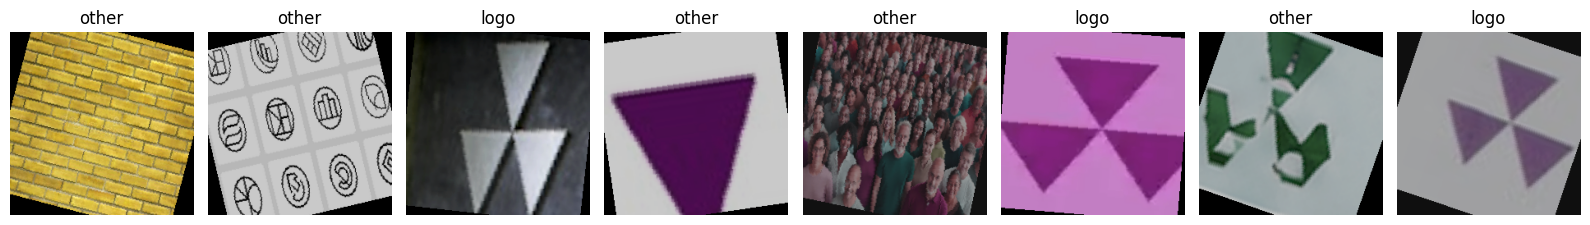

In [ ]:
train_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.3, 0.3, 0.3, 0.1),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
eval_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

class ImgPathDataset(Dataset):
    def __init__(self, paths, labels, tf):
        self.paths, self.labels, self.tf = paths, labels, tf
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, i):
        return self.tf(load_rgb(self.paths[i])), int(self.labels[i])

train_ds = ImgPathDataset(train_paths, train_labels, train_tf)
val_ds   = ImgPathDataset(val_paths,   val_labels,   eval_tf)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False)

# Preview a few augmented training samples
def denorm(t):
    t = t.clone()
    for c in range(3):
        t[c] = t[c] * STD[c] + MEAN[c]
    return t.clamp(0, 1).permute(1, 2, 0).numpy()

imgs, labels = next(iter(train_loader))
fig, ax = plt.subplots(1, 8, figsize=(16, 2.4))
for j in range(8):
    ax[j].imshow(denorm(imgs[j])); ax[j].axis('off')
    ax[j].set_title('logo' if labels[j] == 1 else 'other')
plt.tight_layout(); plt.show()

#6. **CNN Model: Fine-Tuned ResNet-18**

We use a ResNet-18 model pre-trained on the ImageNet dataset. Instead of training the entire network, the early layers are frozen to preserve the general image features learned during pre-training. Only the last residual block (layer4) is fine-tuned so that the model can adapt to the logo classification task.

The original classification layer is replaced with a new fully connected layer consisting of a dropout layer with a rate of 0.5, followed by a linear layer that outputs two classes (logo and other). Dropout helps reduce overfitting by randomly disabling neurons during training, while weight decay, applied during optimization, provides additional regularization. These techniques improve the model's ability to generalize and reduce the overfitting observed in the previous experiment using synthetic data.

Finally, the model is moved to the selected computing device (CPU or GPU), and the number of trainable parameters is displayed.

In [ ]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for p in model.parameters():
    p.requires_grad = False
for name, p in model.named_parameters():
    if name.startswith('layer4'):
        p.requires_grad = True
model.fc = nn.Sequential(nn.Dropout(0.5),
                         nn.Linear(model.fc.in_features, 2))
model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable params: {trainable:,}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 111MB/s]

Trainable params: 8,394,754


# 7. **Training with Weight Decay and Early Stopping**

The model is trained using the Adam optimizer with a learning rate of 0.0001, a weight decay of 0.0001, a batch size of 32, and a maximum of 12 training epochs. A small learning rate allows the model to update its weights gradually, leading to more stable training. The maximum number of epochs is set to 12 to give the model enough time to learn, while early stopping prevents unnecessary training if the model stops improving.

The cross-entropy loss function is used for classification. During training, the training loss, validation loss, and validation accuracy are calculated after each epoch. The model weights with the lowest validation loss are saved. If the validation loss does not improve for three consecutive epochs (patience = 3), training stops early to reduce overfitting.

Because the validation set consists of unseen real images, the validation loss and accuracy provide a reliable measure of the model's ability to generalize to new data.




In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam([p for p in model.parameters() if p.requires_grad],
                             lr=1e-4, weight_decay=1e-4)
MAX_EPOCHS, PATIENCE = 12, 3

best_loss, best_state, bad = float('inf'), None, 0
for epoch in range(1, MAX_EPOCHS + 1):
    model.train(); run = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward(); optimizer.step()
        run += loss.item() * imgs.size(0)
    train_loss = run / len(train_ds)

    model.eval(); vloss, correct = 0.0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model(imgs)
            vloss += criterion(out, labels).item() * imgs.size(0)
            correct += (out.argmax(1) == labels).sum().item()
    val_loss = vloss / max(1, len(val_ds))
    val_acc  = correct / max(1, len(val_ds))
    print(f'Epoch {epoch:2d}/{MAX_EPOCHS}  train_loss={train_loss:.4f}  '
          f'val_loss={val_loss:.4f}  val_acc={val_acc:.3f}')

    if val_loss < best_loss - 1e-4:
        best_loss, bad = val_loss, 0
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        bad += 1
        if bad >= PATIENCE:
            print('Early stopping.'); break

if best_state is not None:
    model.load_state_dict(best_state)
print('Loaded best weights (val_loss = %.4f).' % best_loss)

Epoch  1/12  train_loss=0.0106  val_loss=0.0242  val_acc=0.974
Epoch  2/12  train_loss=0.0068  val_loss=0.0110  val_acc=1.000
Epoch  3/12  train_loss=0.0035  val_loss=0.0055  val_acc=1.000
Epoch  4/12  train_loss=0.0056  val_loss=0.0125  val_acc=0.987
Epoch  5/12  train_loss=0.0039  val_loss=0.0124  val_acc=0.987
Epoch  6/12  train_loss=0.0022  val_loss=0.0106  val_acc=1.000
Early stopping.
Loaded best weights (val_loss = 0.0055).


# 8. **Step 1 - Selective Search (Fast Mode)**

The first step of the R-CNN pipeline is to generate candidate object regions using Selective Search. In this implementation, OpenCV's **Fast** mode ***switchToSelectiveSearchFast()*** is used to efficiently generate region proposals. Fast mode combines image segmentation and region merging to produce a large number of candidate bounding boxes while requiring less computation than the quality mode.

After the region proposals are generated, very small bounding boxes (less than 12 pixels in width or height) are removed because they are unlikely to contain meaningful objects. The remaining proposals are limited to a maximum of 4,000 regions per image to reduce computational cost during the subsequent classification stage.

Fast mode was selected because it provides a good balance between detection performance and processing time, making it suitable for this logo detection task.


In [ ]:
def selective_search(image_bgr, max_rects=4000, min_box=12):
    ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
    ss.setBaseImage(image_bgr)
    ss.switchToSelectiveSearchFast()
    rects = ss.process()                     # often several thousand boxes; each is (x, y, w, h)
    out = [(int(x), int(y), int(w), int(h))
           for (x, y, w, h) in rects if w >= min_box and h >= min_box]
    return np.array(out[:max_rects])

#9. **Step 2 - Region Classification and Non-Maximum Suppression**

Each region proposal generated by Selective Search is resized to 224 × 224 pixels and passed through the fine-tuned ResNet-18 model. The CNN predicts the probability that each proposal contains the target logo. To improve efficiency, the proposals are processed in batches.

Only proposals with a confidence score greater than the predefined threshold (score_thresh) are retained. Since, multiple proposals may overlap and detect the same object, Non-Maximum Suppression (NMS) is applied to remove redundant bounding boxes while preserving the highest-confidence detections.

A diagnostic function is also included to visualize the highest-scoring region proposals regardless of the confidence threshold. This function is useful for analyzing the model's predictions and determining whether missed detections are caused by low classification confidence or by the failure of Selective Search to generate an appropriate region proposal.


In [ ]:
@torch.no_grad()
def _score_proposals(image_bgr, max_rects, min_size, batch_size=64):
    model.eval()
    rects = selective_search(image_bgr, max_rects=max_rects)
    img_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    scored, batch, meta = [], [], []
    def flush():
        if not batch:
            return
        p = torch.softmax(model(torch.stack(batch).to(device)), 1)[:, 1].cpu().numpy()
        scored.extend(zip(meta, p.tolist()))
    for (x, y, w, h) in rects:
        if w < min_size or h < min_size:
            continue
        ar = w / float(h)
        if ar < 0.2 or ar > 5.0:
            continue
        crop = cv2.resize(img_rgb[y:y+h, x:x+w], (IMG_SIZE, IMG_SIZE))
        batch.append(eval_tf(crop)); meta.append((x, y, x + w, y + h))
        if len(batch) == batch_size:
            flush(); batch, meta = [], []
    flush()
    return scored

def detect(image_bgr, score_thresh=0.5, iou_thresh=0.3, max_rects=4000, min_size=16):
    scored = _score_proposals(image_bgr, max_rects, min_size)
    boxes  = [m for m, s in scored if s >= score_thresh]
    scores = [s for m, s in scored if s >= score_thresh]
    if not boxes:
        return [], []
    keep = nms(torch.tensor(boxes, dtype=torch.float32),
               torch.tensor(scores), iou_thresh)
    b = torch.tensor(boxes)[keep].int().tolist()
    s = torch.tensor(scores)[keep].tolist()
    return b, s

def show_detections(image_bgr, boxes, scores):
    vis = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB).copy()
    for (x1, y1, x2, y2), s in zip(boxes, scores):
        cv2.rectangle(vis, (x1, y1), (x2, y2), (255, 0, 0), 3)
        cv2.putText(vis, f'{s:.2f}', (x1, max(0, y1 - 6)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)
    plt.figure(figsize=(10, 8)); plt.imshow(vis); plt.axis('off')
    plt.title(f'Detected {len(boxes)} Doshisha-logo region(s)'); plt.show()

def diagnose(image_bgr, topk=10, max_rects=4000, min_size=16):
    scored = sorted(_score_proposals(image_bgr, max_rects, min_size),
                    key=lambda t: t[1], reverse=True)
    print('proposals scored :', len(scored))
    if scored:
        print('highest logo prob:', round(scored[0][1], 3))
    vis = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB).copy()
    for (x1, y1, x2, y2), s in scored[:topk]:
        cv2.rectangle(vis, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cv2.putText(vis, f'{s:.2f}', (x1, max(0, y1 - 5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)
    plt.figure(figsize=(10, 8)); plt.imshow(vis); plt.axis('off')
    plt.title(f'Top {topk} proposals by logo probability'); plt.show()
    return scored

#10. **Testing on a New Image**

In the final step, a new image containing the Doshisha logo is uploaded and processed by the complete R-CNN pipeline. First, Selective Search in Fast mode generates candidate region proposals. Each proposal is then classified by the fine-tuned ResNet-18 model. Proposals with a confidence score above the selected threshold (score_thresh = 0.5) are retained, and Non-Maximum Suppression (NMS) is applied to remove overlapping detections.

The final detected logo regions are displayed on the original image together with their confidence scores, allowing the detection results to be visually evaluated.


Upload a TEST image:


Saving ph14.jpg to ph14.jpg
Detections: [([381, 260, 411, 288], 1.0), ([368, 235, 424, 296], 0.986)]


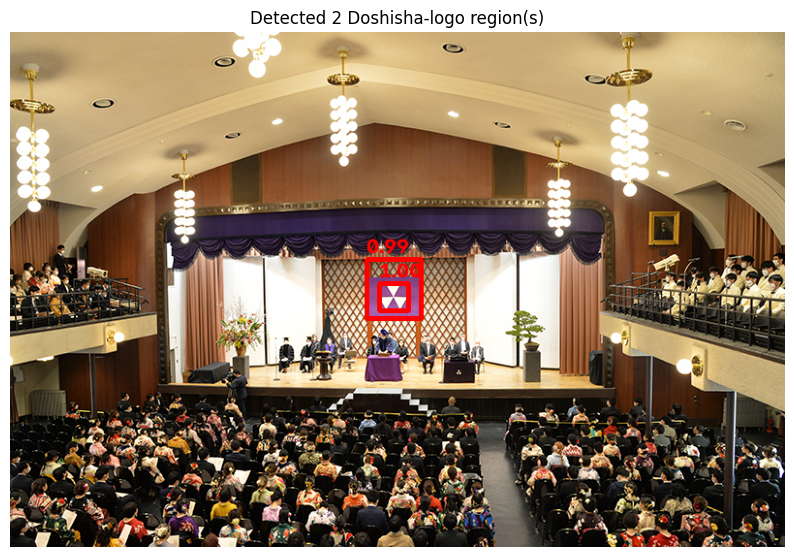

In [ ]:
from google.colab import files

print('Upload a TEST image:')
up = files.upload()
test_path = list(up.keys())[0]
img_bgr = cv2.imread(test_path)
assert img_bgr is not None, 'Could not read the image.'

boxes, scores = detect(img_bgr, score_thresh=0.5, iou_thresh=0.3)
print('Detections:', [(b, round(s, 3)) for b, s in zip(boxes, scores)])
show_detections(img_bgr, boxes, scores)

# 11. **Summary and Limitations**

### **Summary**

In this project, an R-CNN-based logo detector was implemented by combining Selective Search with a fine-tuned ResNet-18 model. First, Selective Search in **Fast** mode generates candidate object regions from the input image. Each region is resized to **224 × 224** pixels and classified by the CNN as either **logo** or **other**. Finally, Non-Maximum Suppression (NMS) removes overlapping detections and keeps the most confident bounding boxes.

Compared with the previous experiment using synthetic images, this implementation provides a more reliable evaluation. The model was trained using real image crops, and the validation set was created before any augmentation or oversampling. In addition, data augmentation, dropout, weight decay, and early stopping were applied to reduce overfitting and improve the model's ability to generalize to unseen images.

### **Limitations**

Although the proposed method is able to detect the Doshisha logo, it has several limitations. First, Selective Search is computationally expensive because it generates a large number of region proposals for each image. As a result, the detection process is slower than modern object detection methods.

Second, the accuracy of the final detection depends on the quality of the generated region proposals. If Selective Search does not produce a proposal that closely matches the logo, the CNN cannot correctly classify it. In addition, this implementation does not include bounding-box regression, so the detected boxes may not tightly fit the logo.

Finally, the dataset used for training is relatively small. Increasing the number and diversity of training images or applying hard-negative mining by adding false positive detections to the negative training set could further improve the detection performance.

